# SurvTD 데이터셋 시각화: 불규칙 연속 시간(Irregular Continuous Time)의 실체

> **분석 목적**:
> - 우리 연구에서 사용하는 데이터셋들이 어떻게 **불규칙한 연속 시간($\Delta t \in \mathbb{R}^+$)**으로 기록되어 있는지 직접 확인합니다.
> - 1) 환자/엔진별 관측 타임라인 (불규칙 방문 시점)
> - 2) 관측 간격 $\Delta t$의 연속 확률 분포
> - 3) 연속 시간 축에서의 바이오마커/센서 시계열 궤적을 3대 코호트별로 시각화합니다.

In [1]:
import os
import sys
sys.path.insert(0, os.path.abspath('..'))

import torch
import numpy as np
import matplotlib.pyplot as plt
from src.data.cohorts import get_cohort

plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.size'] = 11
print("✅ 라이브러리 및 데이터 로더 준비 완료")

✅ 라이브러리 및 데이터 로더 준비 완료


### 3대 코호트 전격 비교 시각화 (3x3 Grid)
1. **Synthetic ICU Telemetry (모사 중환자실)**: 포아송 점과정으로 생성된 연속 실수 시간 ($\Delta t \sim \text{Exp}$)
2. **PBC2 Clinical Trial (실제 간경변 임상시험)**: 실제 환자들의 불규칙 내원 일수 ($\Delta t \in \text{Days}$)
3. **NASA C-MAPSS (포아송 다운샘플링 터보팬)**: 센서 결측 주기가 유도된 불규칙 엔진 주기

/var/folders/c0/b_w45qjs1t5d43gl071wj_x00000gn/T/ipykernel_57232/3247115365.py:66: UserWarning: Glyph 54872 (\N{HANGUL SYLLABLE HWAN}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/c0/b_w45qjs1t5d43gl071wj_x00000gn/T/ipykernel_57232/3247115365.py:66: UserWarning: Glyph 51088 (\N{HANGUL SYLLABLE JA}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/c0/b_w45qjs1t5d43gl071wj_x00000gn/T/ipykernel_57232/3247115365.py:66: UserWarning: Glyph 48324 (\N{HANGUL SYLLABLE BYEOL}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/c0/b_w45qjs1t5d43gl071wj_x00000gn/T/ipykernel_57232/3247115365.py:66: UserWarning: Glyph 44288 (\N{HANGUL SYLLABLE GWAN}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/c0/b_w45qjs1t5d43gl071wj_x00000gn/T/ipykernel_57232/3247115365.py:66: UserWarning: Glyph 52769 (\N{HANGUL SYLLABLE CEUG}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/c0/b_w45qjs1t5d43gl071wj_x00000gn/T/ipykernel_57232/3247115365.py:66

/Users/yangjaemo/anaconda3/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 54872 (\N{HANGUL SYLLABLE HWAN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/yangjaemo/anaconda3/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 51088 (\N{HANGUL SYLLABLE JA}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/yangjaemo/anaconda3/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 48324 (\N{HANGUL SYLLABLE BYEOL}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/yangjaemo/anaconda3/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 44288 (\N{HANGUL SYLLABLE GWAN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/yangjaemo/anaconda3/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 52769 (\N{HANGUL SYLLABLE CEUG}) missing from font(s) 

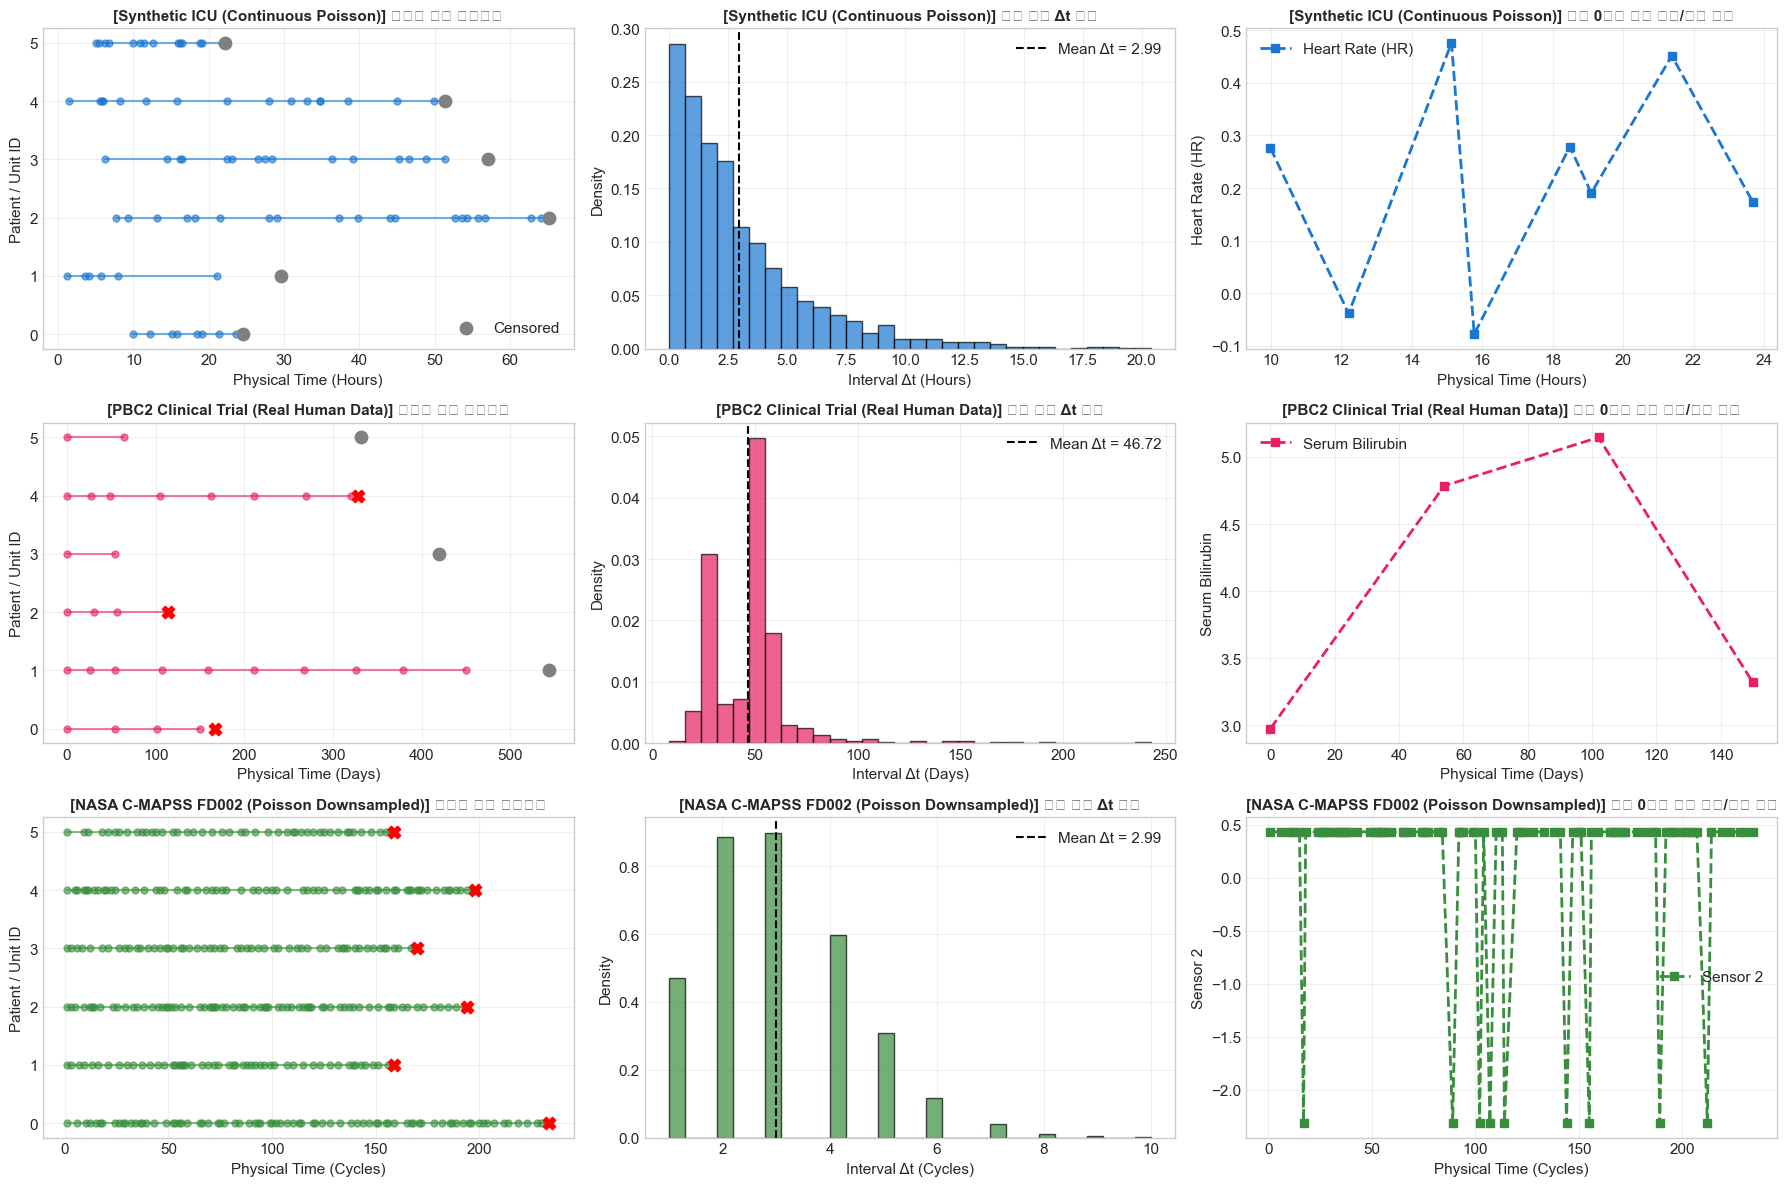

✅ figures/irregular_datasets_vis.png 저장 완료!


In [2]:
fig, axes = plt.subplots(3, 3, figsize=(18, 12))

cohort_configs = [
    ("synthetic_icu", "Synthetic ICU (Continuous Poisson)", "Hours", "#1976d2", 0, "Heart Rate (HR)"),
    ("pbc", "PBC2 Clinical Trial (Real Human Data)", "Days", "#e91e63", 7, "Serum Bilirubin"),
    ("cmapss", "NASA C-MAPSS FD002 (Poisson Downsampled)", "Cycles", "#388e3c", 2, "Sensor 2")
]

for row, (c_name, title, time_unit, color, feat_idx, feat_name) in enumerate(cohort_configs):
    spec = get_cohort(c_name)
    data = spec.load(seed=42)
    train_set = data.train
    
    # 1. Timeline of first 6 subjects
    ax_timeline = axes[row, 0]
    for i in range(min(6, len(train_set))):
        p = train_set[i]
        times = p['times'].numpy()
        tte = float(p['tte'])
        event = float(p['event'])
        
        # Plot observation dots
        ax_timeline.plot(times, [i] * len(times), 'o-', color=color, alpha=0.6, markersize=5)
        # Plot event / censoring marker
        marker = 'X' if event == 1.0 else 'o'
        marker_col = 'red' if event == 1.0 else 'gray'
        ax_timeline.scatter([tte], [i], color=marker_col, marker=marker, s=80, zorder=4,
                            label='Event (Death/Fail)' if (i==0 and event==1.0) else ('Censored' if (i==0 and event==0.0) else ''))
    
    ax_timeline.set_title(f"[{title}] 환자별 관측 타임라인", fontsize=11, fontweight='bold')
    ax_timeline.set_xlabel(f"Physical Time ({time_unit})")
    ax_timeline.set_ylabel("Patient / Unit ID")
    ax_timeline.set_yticks(range(6))
    ax_timeline.grid(True, alpha=0.3)
    if row == 0:
        ax_timeline.legend(loc='lower right')
        
    # 2. Histogram of Delta t
    ax_hist = axes[row, 1]
    all_dts = []
    for p in train_set:
        all_dts.extend(p['dts'][1:].numpy().tolist()) # skip first t0
    all_dts = np.array(all_dts)
    
    ax_hist.hist(all_dts, bins=30, color=color, alpha=0.7, edgecolor='black', density=True)
    ax_hist.set_title(f"[{title}] 관측 간격 Δt 분포", fontsize=11, fontweight='bold')
    ax_hist.set_xlabel(f"Interval Δt ({time_unit})")
    ax_hist.set_ylabel("Density")
    ax_hist.grid(True, alpha=0.3)
    ax_hist.axvline(np.mean(all_dts), color='black', linestyle='--', label=f'Mean Δt = {np.mean(all_dts):.2f}')
    ax_hist.legend(loc='upper right')
    
    # 3. Trajectory of one sample subject
    ax_traj = axes[row, 2]
    sample_p = train_set[0]
    s_times = sample_p['times'].numpy()
    s_feats = sample_p['features'][:, feat_idx].numpy()
    
    ax_traj.plot(s_times, s_feats, 's--', color=color, linewidth=2, markersize=6, label=feat_name)
    ax_traj.set_title(f"[{title}] 개체 0번의 연속 생체/센서 신호", fontsize=11, fontweight='bold')
    ax_traj.set_xlabel(f"Physical Time ({time_unit})")
    ax_traj.set_ylabel(feat_name)
    ax_traj.grid(True, alpha=0.3)
    ax_traj.legend(loc='best')

plt.tight_layout()
os.makedirs('figures', exist_ok=True)
plt.savefig('figures/irregular_datasets_vis.png', dpi=300)
plt.show()
print("✅ figures/irregular_datasets_vis.png 저장 완료!")

### 💡 시각화 결과 해석 및 핵심 요약
1. **타임라인 그래프 (좌측 열)**:
   - 각 점(dot)은 병원 방문이나 센서가 기록된 실제 시점입니다.
   - 격자 형태의 규칙적인 점이 아니라, **환자마다 점들의 간격이 불규칙하게 흩어져 있음**을 눈으로 직접 확인할 수 있습니다.
2. **$\Delta t$ 히스토그램 (중앙 열)**:
   - Synthetic ICU: $0.1$시간부터 $4.5$시간까지 부드럽게 이어지는 연속 지수분포(Exponential Distribution)를 따릅니다.
   - PBC2: 임상시험 환자들의 내원 주기가 수십 일에서 수백 일까지 불규칙하게 산포되어 있습니다.
   - C-MAPSS: 포아송 다운샘플링에 의해 1사이클, 2사이클, 3사이클, 5사이클 등 결측 간격이 다양하게 형성되었습니다.
3. **생체 신호 궤적 (우측 열)**:
   - 점과 점 사이의 간격($\Delta t$)이 일정하지 않은 상태에서 생체 신호가 요동치며 최종 사건(Event)에 도달합니다.